## Tipos de tensores

In [ ]:
import torch
import numpy as np

In [ ]:
lista = [[1,2,3],
         [4,5,6]]

tns = torch.DoubleTensor(lista)
print(tns.dtype)
print(tns)

tns = torch.LongTensor(lista)
print(tns.dtype)
print(tns)

torch.float64
tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64)
torch.int64
tensor([[1, 2, 3],
        [4, 5, 6]])


In [ ]:
arr = np.random.rand(3,4)
#arr =arr.astype(int)
tns = torch.from_numpy(arr)

print(arr)
print(tns)

[[0.58383208 0.76140687 0.61488819 0.56433673]
 [0.05138019 0.39178311 0.8324376  0.82103801]
 [0.47680989 0.40719472 0.64962584 0.8555455 ]]
tensor([[0.5838, 0.7614, 0.6149, 0.5643],
        [0.0514, 0.3918, 0.8324, 0.8210],
        [0.4768, 0.4072, 0.6496, 0.8555]], dtype=torch.float64)


In [ ]:
#criar tensor vazio

tns = torch.ones(3,3)
tns1 = torch.zeros(4,5)
tns2 = torch.randn(3,3)
tns1[1,3] = -10

print(tns)
print(tns1)
print(tns2)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
tensor([[  0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0., -10.,   0.],
        [  0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.]])
tensor([[-0.5906, -0.8177,  0.8456],
        [ 2.3507,  0.1003, -0.4132],
        [-0.2313,  1.1640, -2.0626]])


In [ ]:
arr = tns2.data.numpy()
print(arr)

[[-0.59060436 -0.81765395  0.845617  ]
 [ 2.3506734   0.10029349 -0.41323203]
 [-0.23125812  1.163997   -2.0626237 ]]


In [ ]:
tns2.data

tensor([[-0.5906, -0.8177,  0.8456],
        [ 2.3507,  0.1003, -0.4132],
        [-0.2313,  1.1640, -2.0626]])

In [ ]:
#tns2[0:2]
#tns2.shape
tns2[:,2]

tensor([ 1.6386,  1.4751, -1.2573])

In [ ]:
print(tns2+tns)
print(torch.mm(tns2,tns.T)) # para multiplicação determinada usar assim
#tns2* tns multiplica ponta a ponta somente

tensor([[ 0.4094,  0.1823,  1.8456],
        [ 3.3507,  1.1003,  0.5868],
        [ 0.7687,  2.1640, -1.0626]])
tensor([[-0.5626, -0.5626, -0.5626],
        [ 2.0377,  2.0377,  2.0377],
        [-1.1299, -1.1299, -1.1299]])


In [ ]:
# achatar tensor
tns2 = tns2.view(9)
print(tns2)

tensor([-0.5906, -0.8177,  0.8456,  2.3507,  0.1003, -0.4132, -0.2313,  1.1640,
        -2.0626])


In [ ]:
# achatar tensor mantendo primeira dimensão
tns2 = tns2.view(tns2.size(0),-1)
print(tns2)

tensor([[-0.5906],
        [-0.8177],
        [ 0.8456],
        [ 2.3507],
        [ 0.1003],
        [-0.4132],
        [-0.2313],
        [ 1.1640],
        [-2.0626]])


In [ ]:
# verificar gpu disponível

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

tns1 = tns1.to(device)
print(tns1)

cpu
tensor([[  0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0., -10.,   0.],
        [  0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.]])


In [ ]:
#concatenação de tensores
tns2 = torch.randn(3,3)
tns_out = torch.cat( (tns, tns2), dim=0 )
tns_out

tensor([[ 1.0000,  1.0000,  1.0000],
        [ 1.0000,  1.0000,  1.0000],
        [ 1.0000,  1.0000,  1.0000],
        [ 0.4929, -0.3978,  1.6386],
        [-0.1912,  1.4321,  1.4751],
        [ 0.8872,  1.8210, -1.2573]])

Passos:

* Inspiração biológica de redes neurais.
* Perceptron: a unidade fundamental de redes neurais.
* Inverno da I.A. (Limitação do Perceptron).
* Teorema da Aproximação Universal.
* Tensores como estrutura de dados.
* Manipulação de tensores no Pytorch.
* Colocando tensores na GPU.

## Estudo Classificação Linear

Ponto abaixo da reta traz valor negativo de retorno e os acima traz valor positivo de retorno

1


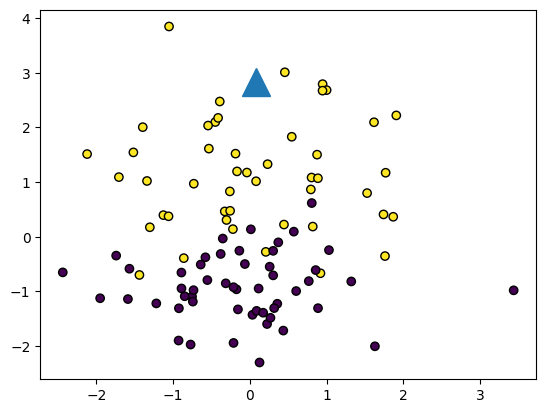

In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(40)

X, Y = make_classification(n_features=2, n_redundant=0, n_informative=1,
                             n_clusters_per_class=1)

plt.scatter(X[:, 0], X[:, 1], marker='o', c=Y,
           edgecolor='k')

p = X[11]
print(Y[11])
plt.plot(p[0], p[1], marker='^', markersize=20)

Gráfico dividido por cor de acordo com a classe(Y). E foi feita uma análise para descobrir que cor amarela é da classe 1

7


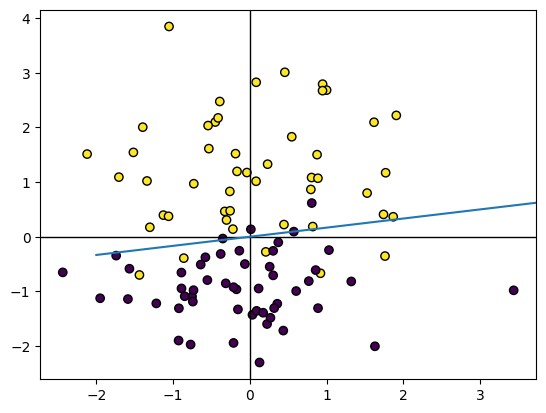

In [ ]:
def plotmodel(w1, w2, b):

  plt.scatter(X[:, 0], X[:, 1], marker='o', c=Y,
           edgecolor='k')

  xmin, xmax = plt.gca().get_xlim() #limitar grade de visuzalização de acordo com tamanho max de eixos
  ymin, ymax = plt.gca().get_ylim()

  x = np.linspace(-2, 4, 50)
  y = (-w1*x -b)/w2

  plt.axvline(0, -1, 1, color='k', linewidth=1)
  plt.axhline(0, -2, 4, color='k', linewidth=1)
  plt.plot(x, y, label='_nolegend_')

  plt.xlim(xmin, xmax)
  plt.ylim(ymin, ymax)

w1 = 1 #a
w2 = -6  #b
b  = 0  #c
plotmodel(w1, w2, b)

p = (1, -1)
print(w1 * p[0] + w2 * p[1] + b)

Assim, fica claro que retornos positivos significam ser da classe azul.

Agora podemos utilizar o nosso modelo como um classificador linear com um simples if para avaliar a solução da equação da reta para novos pontos no espaço.

0 blue


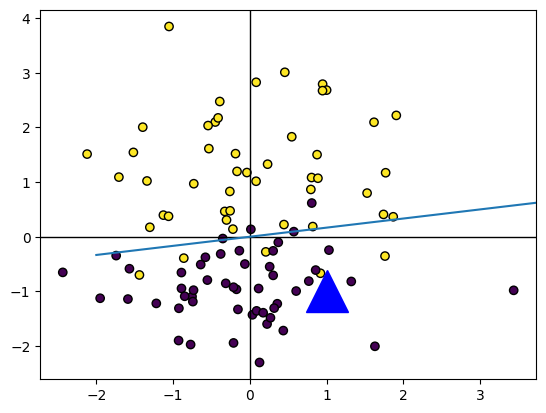

In [ ]:
def classify(ponto, w1, w2, b):
  ret = w1 * ponto[0] + w2 * ponto[1] + b

  if ret >= 0:
    return 0, 'blue'
  else:
    return 1, 'yellow'

p = (1, -1)
classe, cor = classify(p, w1, w2, b)
print(classe, cor)

plotmodel(w1,w2, b)
plt.plot(p[0], p[1], marker='^', color=cor, markersize=30)

In [ ]:
acertos = 0
for k in range(len(X)):
  categ, _ = classify(X[k], w1, w2, b)
  if categ == Y[k]:
    acertos += 1


print("Acurácia: {0}".format(100*acertos/len(X)))

Acurácia: 92.0


## Trabalhando com Perceptron com Pytorch

In [ ]:
import torch
from torch import nn

In [ ]:
torch.manual_seed(40)

perceptron = nn.Linear(in_features=3, out_features=1)
print(perceptron)

Linear(in_features=3, out_features=1, bias=True)


In [ ]:
for nome, tensor in perceptron.named_parameters():
  print(nome, tensor)

print('')
print(perceptron.weight.data)
print(perceptron.bias.data)

weight Parameter containing:
tensor([[ 0.3668, -0.0489,  0.5310]], requires_grad=True)
bias Parameter containing:
tensor([0.3706], requires_grad=True)

tensor([[ 0.3668, -0.0489,  0.5310]])
tensor([0.3706])


In [ ]:
w1, w2, w3 = perceptron.weight.data.numpy()[0]
b = perceptron.bias.data.numpy()
#w1 * x1 + w2 * x2 + w3 + b = 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3d(perceptron):

  w1, w2, w3 = perceptron.weight.data.numpy()[0]
  b = perceptron.bias.data.numpy()

  X1 = np.linspace(-1,1,10)
  X2 = np.linspace(-1,1,10)

  X1, X2 = np.meshgrid(X1,X2)

  X3 = (b - w1*X1 - w2*X2) / w3

  fig = plt.figure(figsize=(10, 8))

  ax = fig.add_subplot(111, projection='3d')

  ax.view_init(azim=180)

  ax.plot_surface(X1, X2, X3, cmap='plasma')



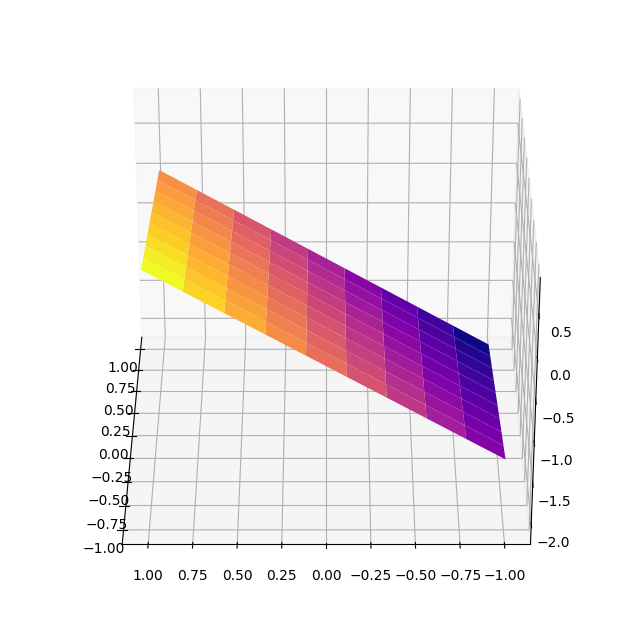

In [ ]:
plot3d(perceptron)

É importante não se esquecer que no perceptron esses valores definem um hiperplano no espaço. Como 3 dimensões está no limite da nossa capacidade de visualização, vamos aproveitar esse momento para visualizar o plano aleatoriamente inicializado pelo torch.

O fluxo da informação de entrada através da rede recebe o nome de forward, já que a informação é passada para a frente. Vamos então realizar o forward da nossa rede de um perceptron só. Para isso, basta realizar uma chamada de função com a variável onde instaciamos a camada Linear.

tensor([-0.7746], grad_fn=<ViewBackward0>)


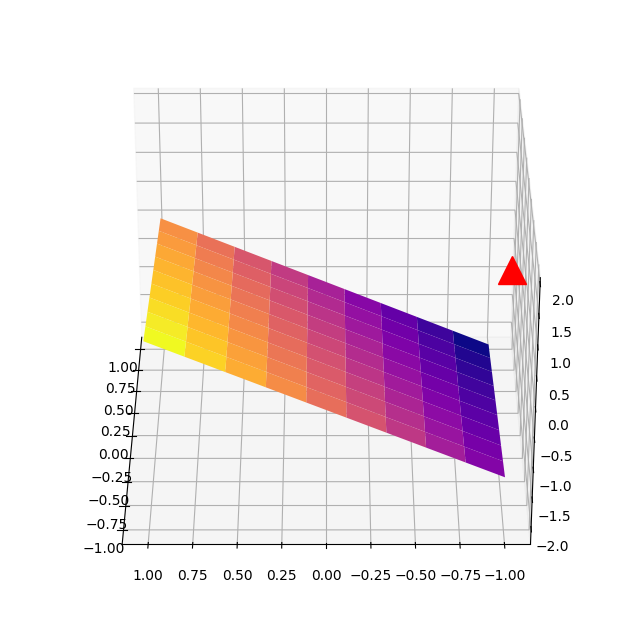

In [ ]:
X = torch.Tensor([-1, -1, 2])
y = perceptron(X)

print(y)

plot3d(perceptron)
plt.plot([X[0]], [X[1]], [X[2]], color='r', marker='^', markersize=20)

Acima da camada retorno é negativo e abaixo é postitivo, ou seja, essa é a transformação linear do perceptron na prática para determinados pontos.

## Funções de Ativação

In [ ]:
import torch
from torch import nn

In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(40)

X, Y = make_classification(n_features=2, n_redundant=0, n_informative=1,
                             n_clusters_per_class=1)

7


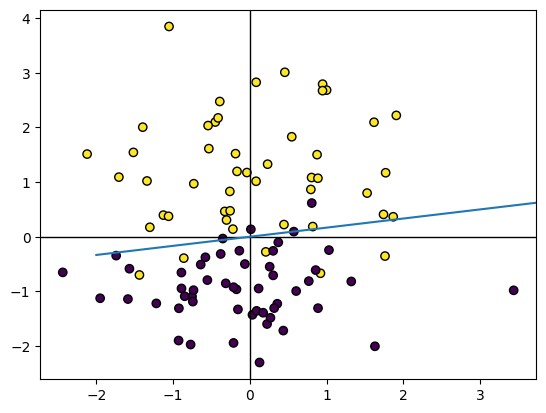

In [ ]:
def plotmodel(w1, w2, b):

  plt.scatter(X[:, 0], X[:, 1], marker='o', c=Y,
           edgecolor='k')

  xmin, xmax = plt.gca().get_xlim() #limitar grade de visuzalização de acordo com tamanho max de eixos
  ymin, ymax = plt.gca().get_ylim()

  x = np.linspace(-2, 4, 50)
  y = (-w1*x -b)/w2

  plt.axvline(0, -1, 1, color='k', linewidth=1)
  plt.axhline(0, -2, 4, color='k', linewidth=1)
  plt.plot(x, y, label='_nolegend_')

  plt.xlim(xmin, xmax)
  plt.ylim(ymin, ymax)

w1 = 1 #a
w2 = -6  #b
b  = 0  #c
plotmodel(w1, w2, b)

p = (1, -1)
print(w1 * p[0] + w2 * p[1] + b)

In [ ]:
perceptron = nn.Linear(2, 1)
sigmoid = nn.Sigmoid()

print(perceptron.weight.data)
print(perceptron.bias.data)

tensor([[ 0.6555, -0.1855]])
tensor([-0.6740])


In [ ]:
w1 = 1 #a
w2 = -6  #b
b  = 0  #c

#modificar para o modelo que já treinamos na mão
perceptron.weight = nn.Parameter(torch.Tensor([[w1, w2]]))
perceptron.bias = nn.Parameter(torch.Tensor([b]))

print(perceptron.weight.data)
print(perceptron.bias.data)

tensor([[ 1., -6.]])
tensor([0.])


### Função Sigmoid

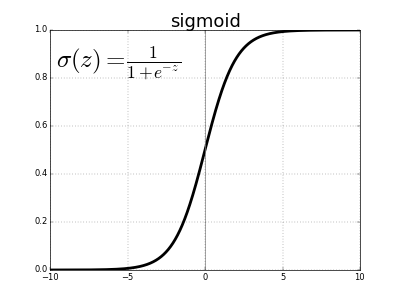

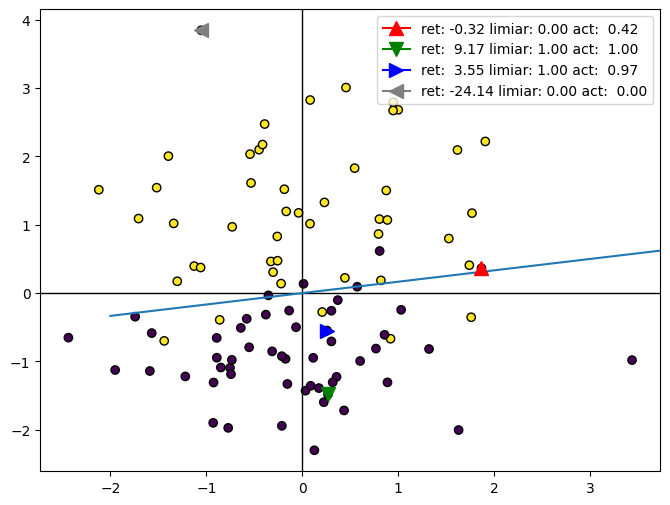

In [ ]:
activation = nn.Sigmoid()

markers = ['^', 'v', '>', '<']
colors = ['r', 'g', 'b', 'gray']

plt.figure(figsize=(8, 6))
plotmodel(w1, w2, b)
for k, idx in enumerate([12, 64, 29, 65]):
  x = torch.Tensor(X[idx])

  ret = perceptron(x)
  act = activation(ret)

  act_limiar = 0 if ret.data < 0 else 1

  label = 'ret: {:5.2f}'.format(ret.data.numpy()[0]) + ' limiar: {:4.2f}'.format(act_limiar) + ' act: {:5.2f}'.format(act.data.numpy()[0])
  plt.plot(x[0], x[1], marker=markers[k], color=colors[k], markersize=10, label=label)

plt.legend()
plt.show()

### Função Tanh

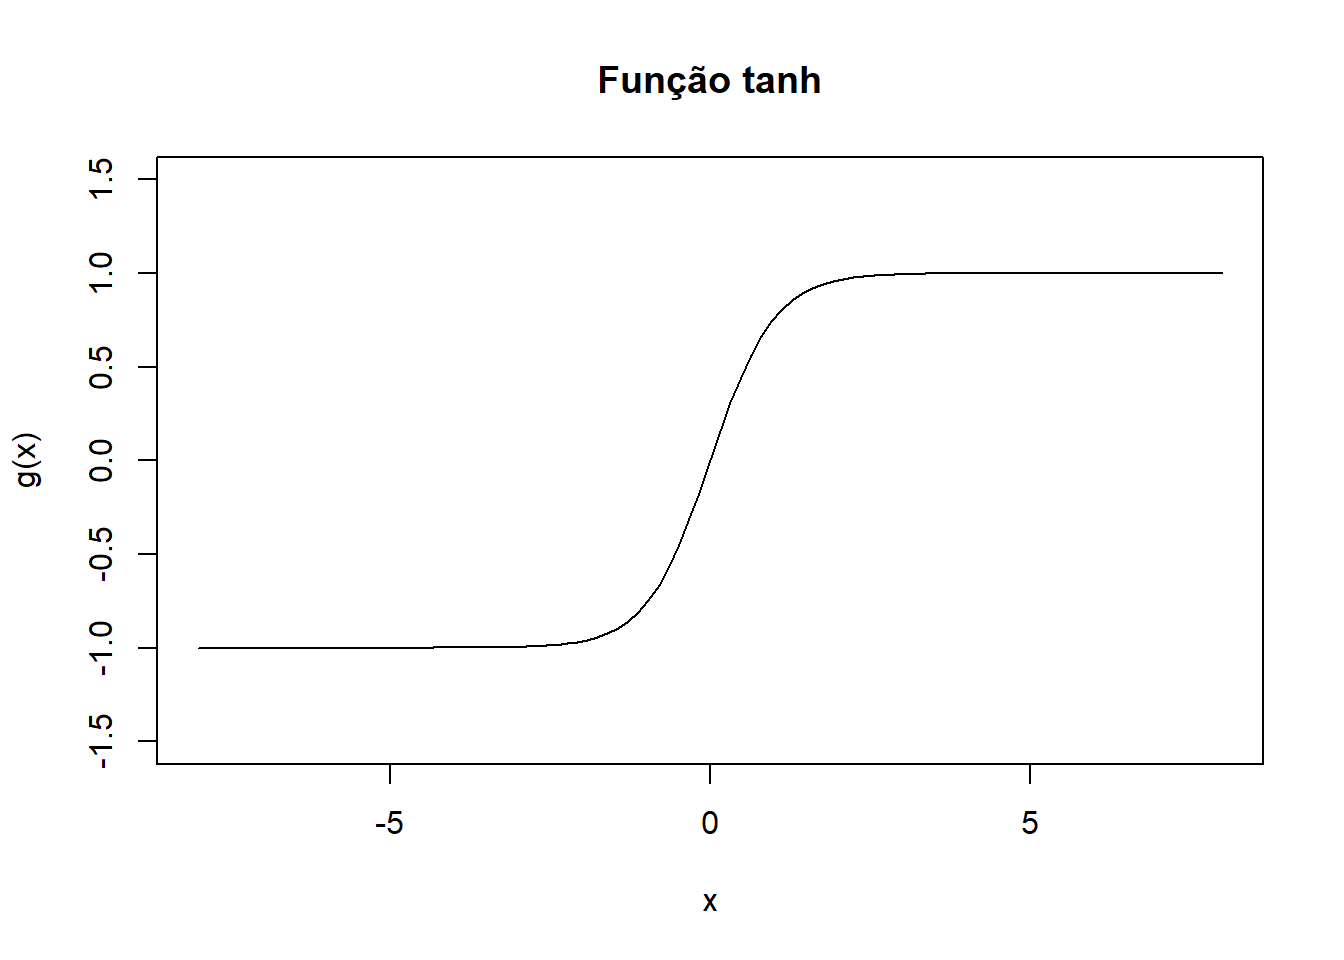

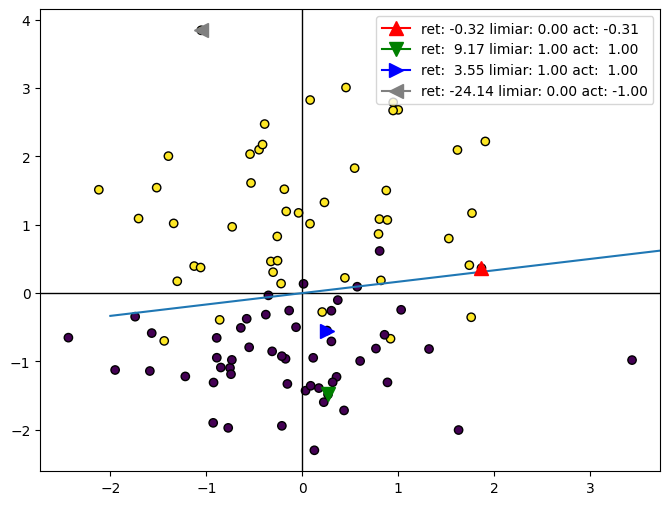

In [ ]:
activation = nn.Tanh()

markers = ['^', 'v', '>', '<']
colors = ['r', 'g', 'b', 'gray']

plt.figure(figsize=(8, 6))
plotmodel(w1, w2, b)
for k, idx in enumerate([12, 64, 29, 65]):
  x = torch.Tensor(X[idx])

  ret = perceptron(x)
  act = activation(ret)

  act_limiar = 0 if ret.data < 0 else 1

  label = 'ret: {:5.2f}'.format(ret.data.numpy()[0]) + ' limiar: {:4.2f}'.format(act_limiar) + ' act: {:5.2f}'.format(act.data.numpy()[0])
  plt.plot(x[0], x[1], marker=markers[k], color=colors[k], markersize=10, label=label)

plt.legend()
plt.show()

### Função ReLU

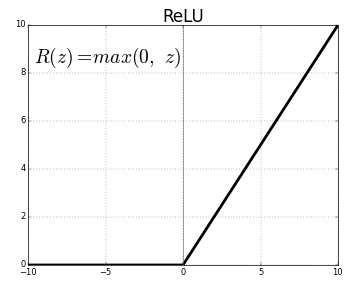

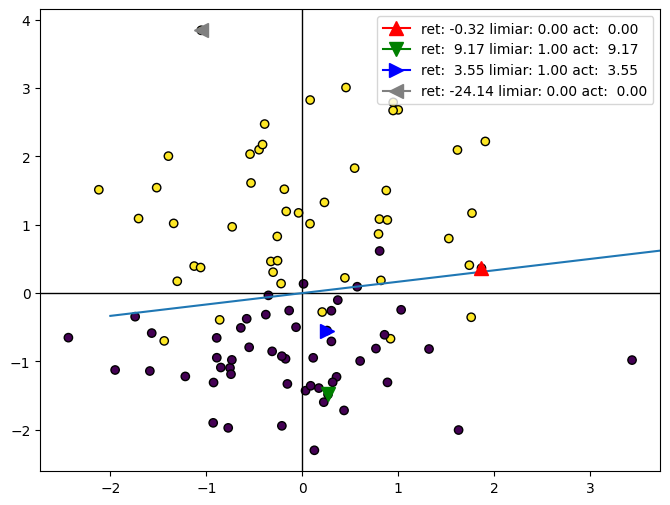

In [ ]:
activation = nn.ReLU()

markers = ['^', 'v', '>', '<']
colors = ['r', 'g', 'b', 'gray']

plt.figure(figsize=(8, 6))
plotmodel(w1, w2, b)
for k, idx in enumerate([12, 64, 29, 65]):
  x = torch.Tensor(X[idx])

  ret = perceptron(x)
  act = activation(ret)

  act_limiar = 0 if ret.data < 0 else 1

  label = 'ret: {:5.2f}'.format(ret.data.numpy()[0]) + ' limiar: {:4.2f}'.format(act_limiar) + ' act: {:5.2f}'.format(act.data.numpy()[0])
  plt.plot(x[0], x[1], marker=markers[k], color=colors[k], markersize=10, label=label)

plt.legend()
plt.show()

ReLU não é apropriada para esse tipo de aplicação, pois precisamos ter certeza sobre a fronteira de decisão.

Com a sigmoid e tanh, elementos na fronteira de decisão recebem o valor 0.5, indicando baixa certeza sobre a classe desses elementos. Quanto mais afasta da zona de confusão, maior a certeza da classificação (seja para 0, ou para 1).

## Problema não linearmente separável


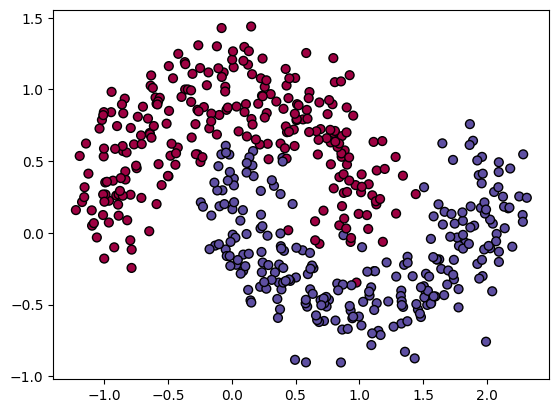

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=500, noise=0.2, random_state=50)

plt.scatter(X[:, 0], X[:, 1], s=40, c=y, cmap=plt.cm.Spectral, edgecolor ='k')

In [ ]:
import torch
from torch import nn

input_size = 2
hidden_size = 8
output_size = 1

net = nn.Sequential(nn.Linear(in_features=input_size, out_features=hidden_size),
                    nn.ReLU(),
                    nn.Linear(hidden_size, output_size))

print(net)

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
from torchsummary import summary

summary(net, input_size=(1, input_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1, 8]              24
              ReLU-2                 [-1, 1, 8]               0
            Linear-3                 [-1, 1, 1]               9
Total params: 33
Trainable params: 33
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


#### Forward

In [ ]:
print(X.dtype)
tensor = torch.from_numpy(X).float() #Redes são carregadas com float32
pred = net(tensor)
print(X.shape)
print(pred.size())

float64
(500, 2)
torch.Size([500, 1])


### Usando nnModule

In [ ]:
class model(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(model, self).__init__()
    #Definir arquitetura
    self.hidden = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self,X):
    #Gerar saída à partir do X
    hidden = self.relu(self.hidden(X))
    output = self.output(hidden)
    return output


In [ ]:
input_size = 2
hidden_size = 8
output_size = 1

net = model(input_size, hidden_size, output_size) #método __init__()
print(net)

model(
  (hidden): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
print(X.dtype)
tensor = torch.from_numpy(X).float() #Redes são carregadas com float32
pred = net(tensor)
print(X.shape)
print(pred.size())

float64
(500, 2)
torch.Size([500, 1])


#### Usando na GPU

In [ ]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

print(device)

cpu


In [ ]:
input_size = 2
hidden_size = 8
output_size = 1

net = model(input_size, hidden_size, output_size) #método __init__()
net = net.to(device)
print(net)

model(
  (hidden): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
print(X.dtype)
tensor = torch.from_numpy(X).float() #Redes são carregadas com float32
tensor = tensor.to(device)
#print(tensor)
pred = net(tensor)
# print(X.shape)
print(pred.size())

float64
torch.Size([500, 1])


# Segundo exemplo de rede com pytorch

Modelo para classificação com 3 classes e necessidade de transformar os arrays do numpy Xtreino,X_teste,y_treino,y_teste em tensores.

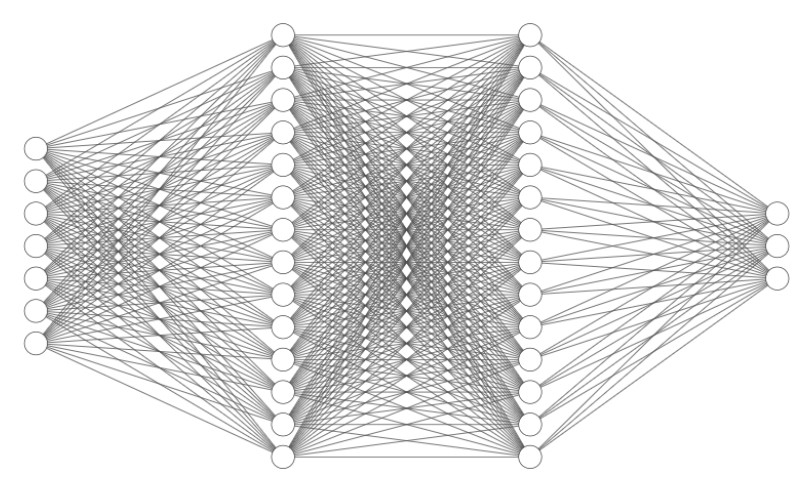

In [ ]:
#Dados e separação treino e teste
X = dados.drop(['Espécie'],axis=1).values
y = dados['Espécie'].values

from sklearn.model_selection import train_test_split
X_treino,X_teste,y_treino,y_teste = train_test_split(X,y,test_size=0.2)

#------------------------------------------------------------------------
#Conversão para tensores
import torch
X_treino = torch.FloatTensor(X_treino)
X_teste = torch.FloatTensor(X_teste)
y_treino = torch.LongTensor(y_treino)
y_teste = torch.LongTensor(y_teste)

#------------------------------------------------------------------------
import torch.nn as nn
import torch.nn.functional as F
class Modelo(nn.Module):
  def __init__(self,entrada=7,camada_escondida1=14,camada_escondida2=49,saida=3):
      super().__init__()
      self.fc1 = nn.Linear(entrada,camada_escondida1)
      self.fc2 = nn.Linear(camada_escondida1, camada_escondida2)
      self.out = nn.Linear(camada_escondida2, saida)
  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

#------------------------------------------------------------------------
modelo_classificacao = Modelo()
funcao_objetivo = nn.CrossEntropyLoss()

'''
verificar se a rede está levando a entrada
para um resultado próximo da saída desejada usando função de custo.

fazer a correção dos pesos aleatórios que a rede fornece na primeira
iteração usando um otimizador. Ideal para verificar o menor loss da curva
gradiente.
'''
otimizador = torch.optim.Adam(modelo_classificacao.parameters(), lr=0.01)

#------------------------------------------------------------------------
# Treinamento do modelo corrigindo os pesos
epocas = 100
custos = []
for i in range(epocas):
  y_predito = modelo_classificacao.forward(X_treino)
  custo = funcao_objetivo(y_predito, y_treino)
  custos.append(custo)

  otimizador.zero_grad()
  custo.backward()
  otimizador.step()

#------------------------------------------------------------------------
# Geração de df com valores preditos e reais
preds = []
with torch.no_grad():
    for val in X_teste:
        y_predito = modelo_classificacao.forward(val)
        preds.append(y_predito.argmax().item())
df = pd.DataFrame({'Y': y_teste, 'YHat': preds})
df['Correto'] = [1 if corr == pred else 0 for corr, pred in zip(df['Y'], df['YHat'])]
df


## Passos:

* Inspiração biológica de redes neurais.
* Perceptron: a unidade fundamental de redes neurais.
* Inverno da I.A. (Limitação do Perceptron).
* Teorema da Aproximação Universal.
* Tensores como estrutura de dados.
* Manipulação de tensores no Pytorch.
* Colocando tensores na GPU.
* Modelos lineares.
* Retas como classificadores lineares.
* Perceptron como classificador linear.
* Camada Linear do PyTorch para criar um Perceptron.
* Papel da função de ativação no perceptron.
* Funções limiar, sigmoide, Tanh e ReLU.
* Funções de ativação no PyTorch.
* Problemas multi-classe.
* Multi-Layer Perceptron (MLP).
* Implementando uma arquitetura com nn.Sequential.
* Implementando uma arquitetura com nn.Module.